# Project Optimal Infill Density
- This is to assess the PLA Experimental Dataset and know the nature of the data.
- Various Analysis Testing will be used in order to explore relationship between data features.
- Graphs and other statistical methods are considered based on the expected results and supporting articles on what methods will be needed in order to arrive to a statistically sound result.

## Setup the specifics of the seaborn layout (theme, font, figure size, etc.)

## 1. Importing necessary libraries and Loading Dataset

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math

# To avoid displaying FutureWarnings from pandas/numpy
warnings.filterwarnings('ignore', category=FutureWarning)

# Allow to show all columns when printing dataframes
pd.set_option('display.max_columns', None)

# Set seaborn theme for better aesthetics
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("PAASE Experiment (PLA).csv", header=0)


## 2. First Look at the Data

In [46]:
# Showing first 10 data entries of the dataset
df.head(10)

,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_actual,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,yield_stress_mpa,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:04:53,15:14:15,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,09:22,1.41,1.44,0.014,NaN,36.1809,1.48981,Nagbedlevel kaya matagal (randomly)
1,2,4/14/2026,15:15:57,15:23:30,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:33,1.40,1.44,0.013,NaN,35.8098,1.68293,NaN
2,3,4/14/2026,15:25:15,15:33:12,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:57,1.40,1.44,0.013,NaN,33.5701,1.92406,NaN
3,4,4/14/2026,15:34:26,15:42:32,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,08:06,1.40,1.44,0.013,NaN,36.1737,1.59461,NaN
4,5,4/14/2026,15:43:59,15:51:56,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,07:57,1.41,1.44,0.013,NaN,36.8314,1.54971,NaN
5,6,4/14/2026,16:47:31,16:55:32,PLA_20_R1,1,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.46,1.49,0.011,NaN,39.4499,1.79080,NaN
6,7,4/14/2026,16:56:54,17:04:55,PLA_20_R2,2,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.46,1.49,0.012,NaN,40.0884,1.74284,NaN
7,8,4/14/2026,17:06:30,17:14:31,PLA_20_R3,3,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.46,1.49,0.013,NaN,39.4338,1.62457,NaN
8,9,4/14/2026,17:16:11,17:24:19,PLA_20_R4,4,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:08,1.47,1.49,0.012,NaN,39.0098,1.69346,NaN
9,10,4/14/2026,17:27:02,17:35:03,PLA_20_R5,5,20,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:15,08:01,1.47,1.49,0.013,NaN,37.7365,1.71288,NaN


In [39]:
# Print summary info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   item_no                 50 non-null     int64  
 1   print_date              50 non-null     str    
 2   start_time              50 non-null     str    
 3   end_time                50 non-null     str    
 4   specimen_id             50 non-null     str    
 5   replicate_no            50 non-null     int64  
 6   infill_density_percent  50 non-null     int64  
 7   infill_pattern          50 non-null     str    
 8   material_type           50 non-null     str    
 9   layer_height_mm         50 non-null     float64
 10  nozzle_temp_c           50 non-null     int64  
 11  bed_temp_c              50 non-null     int64  
 12  wall_count              50 non-null     int64  
 13  top_layers              50 non-null     int64  
 14  bottom_layers           50 non-null     int64  
 15  pr

## 3. Data Quality Assessment

### Checking Missing Values

CHECKING MISSING VALUES
                            Column  Missing_Count  Missing_Percentage
yield_stress_mpa  yield_stress_mpa             50               100.0
remarks                    remarks             48                96.0


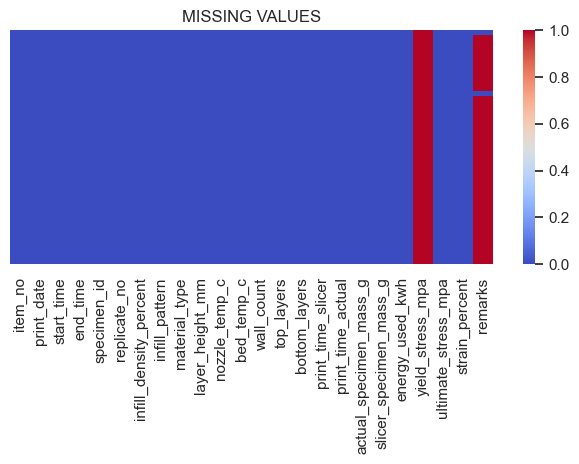

In [40]:
#Checking for Missing Values
print("="*100)
print(str.upper("Checking Missing Values"))
print("=" * 100)

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing) == 0:
    print("No missing values found!")
else:
    print(missing)

# Visualize missing values
if df.isnull().sum().sum() > 0:
    sns.heatmap(df.isnull(), cbar=True, cmap='coolwarm', yticklabels=False)
    plt.title(str.upper('Missing Values'))
    plt.tight_layout()
    plt.show()

### Checking for Duplciates

In [41]:
# Check for duplicates
print("=" * 100)
print(str.upper("Duplciate Values"))
print("=" * 100)
duplicates = df.duplicated().sum()
print(f"Total Duplicates: {duplicates}")
print(f"Percentage: {(duplicates/len(df)*100).round(2)}%")

if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

DUPLCIATE VALUES
Total Duplicates: 0
Percentage: 0.0%


In [42]:
# Adding '00:' prefix to convert to hh:mm:ss format for pd.to_timedelta (prev data was in mm:ss format)
actual_print_time_col = pd.to_timedelta('00:' + df['print_time_actual'])
slicer_print_time_col = pd.to_timedelta('00:' + df['print_time_slicer'])

# Converting 'print_time_slicer' and 'print_time_actual' from hh:mm:ss format to numeric in order to perform calculations
actual_print_time_numeric = (actual_print_time_col.dt.total_seconds() / 3600).round(4)  # Convert to hours and round to 4 decimal places
slicer_print_time_numeric = (slicer_print_time_col.dt.total_seconds() / 3600).round(4)  # Convert to hours and round to 4 decimal places

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Specimen ID': df['specimen_id'],
    'Actual (hours)': actual_print_time_numeric,
    'Slicer (hours)': slicer_print_time_numeric
})
print(results_df.to_string(index=False))

# Print the data types to confirm they are numeric
print('\nData Types After Conversion:',
      '\nactual_print_time_numeric dtype:', actual_print_time_numeric.dtype, 
      '\nslicer_print_time_numeric dtype:', slicer_print_time_numeric.dtype)

Specimen ID  Actual (hours)  Slicer (hours)
  PLA_10_R1          0.1561          0.0536
  PLA_10_R2          0.1258          0.0536
  PLA_10_R3          0.1325          0.0536
  PLA_10_R4          0.1350          0.0536
  PLA_10_R5          0.1325          0.0536
  PLA_20_R1          0.1336          0.0542
  PLA_20_R2          0.1336          0.0542
  PLA_20_R3          0.1336          0.0542
  PLA_20_R4          0.1356          0.0542
  PLA_20_R5          0.1336          0.0542
  PLA_30_R1          0.1372          0.0544
  PLA_30_R2          0.1339          0.0544
  PLA_30_R3          0.1336          0.0544
  PLA_30_R4          0.1628          0.0544
  PLA_30_R5          0.1333          0.0544
  PLA_40_R1          0.1664          0.0550
  PLA_40_R2          0.1367          0.0550
  PLA_40_R3          0.1344          0.0550
  PLA_40_R4          0.1342          0.0550
  PLA_40_R5          0.1342          0.0550
  PLA_50_R1          0.1364          0.0572
  PLA_50_R2          0.1344     

In [43]:
# Insert the new numeric columns back into the original DataFrame for further analysis
df.insert(loc=df.columns.get_loc('print_time_actual') + 1, column='print_time_actual_conv', value=actual_print_time_numeric)
df.insert(loc=df.columns.get_loc('print_time_slicer') + 1, column='print_time_slicer_conv', value=slicer_print_time_numeric)

# Print the updated DataFrame with the new columns
df.head(5)

,item_no,print_date,start_time,end_time,specimen_id,replicate_no,infill_density_percent,infill_pattern,material_type,layer_height_mm,nozzle_temp_c,bed_temp_c,wall_count,top_layers,bottom_layers,print_time_slicer,print_time_slicer_conv,print_time_actual,print_time_actual_conv,actual_specimen_mass_g,slicer_specimen_mass_g,energy_used_kwh,yield_stress_mpa,ultimate_stress_mpa,strain_percent,remarks
0,1,4/14/2026,15:04:53,15:14:15,PLA_10_R1,1,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,0.0536,09:22,0.1561,1.41,1.44,0.014,NaN,36.1809,1.48981,Nagbedlevel kaya matagal (randomly)
1,2,4/14/2026,15:15:57,15:23:30,PLA_10_R2,2,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,0.0536,07:33,0.1258,1.40,1.44,0.013,NaN,35.8098,1.68293,NaN
2,3,4/14/2026,15:25:15,15:33:12,PLA_10_R3,3,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,0.0536,07:57,0.1325,1.40,1.44,0.013,NaN,33.5701,1.92406,NaN
3,4,4/14/2026,15:34:26,15:42:32,PLA_10_R4,4,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,0.0536,08:06,0.1350,1.40,1.44,0.013,NaN,36.1737,1.59461,NaN
4,5,4/14/2026,15:43:59,15:51:56,PLA_10_R5,5,10,gyroid,Sunlu PLA,0.2,220,50,2,5,5,03:13,0.0536,07:57,0.1325,1.41,1.44,0.013,NaN,36.8314,1.54971,NaN
